In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PROC = '../data/processed/'
print('OK')

OK


In [2]:
df = pd.read_csv(PROC + 'df_site40_merged.csv', parse_dates=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
df.head(3)

Shape: (16995, 12)
Colunas: ['obs_id', 'SiteId', 'Timestamp', 'ForecastId', 'Value', 'hour', 'dayofweek', 'month', 'is_weekend', 'Temperature', 'hour_num', 'is_holiday']


,obs_id,SiteId,Timestamp,ForecastId,Value,hour,dayofweek,month,is_weekend,Temperature,hour_num,is_holiday
0,5338068,40,2015-07-03 14:30:00+00:00,1002,6997.984367,14,4,7,0,31.0,14,0
1,3210822,40,2015-07-03 15:30:00+00:00,1002,15518.012898,15,4,7,0,33.0,15,0
2,412101,40,2015-07-03 16:30:00+00:00,1002,6674.491991,16,4,7,0,34.0,16,0


In [3]:
def cyclical_encode(series, period):
    """Codifica uma variável cíclica em componentes seno e cosseno."""
    s = np.sin(2 * np.pi * series / period)
    c = np.cos(2 * np.pi * series / period)
    return s, c

# Hora do dia (período=24) — mesmo do TCC2, porém com minutos quando disponível
df['hour'] = df['Timestamp'].dt.hour
df['minute'] = df['Timestamp'].dt.minute
hour_float = df['hour'] + df['minute'] / 60.0
df['hr_sin'], df['hr_cos'] = cyclical_encode(hour_float, 24)  # TCC2 original

# Dia da semana (período=7) — NOVO
df['dayofweek'] = df['Timestamp'].dt.dayofweek
df['dow_sin'], df['dow_cos'] = cyclical_encode(df['dayofweek'], 7)

# Mês do ano (período=12) — NOVO
df['month'] = df['Timestamp'].dt.month
df['month_sin'], df['month_cos'] = cyclical_encode(df['month'], 12)

print('Encoding cíclico aplicado:')
print(df[['Timestamp','hr_sin','hr_cos','dow_sin','dow_cos','month_sin','month_cos']].head(5).to_string())

Encoding cíclico aplicado:
                  Timestamp    hr_sin    hr_cos   dow_sin   dow_cos  month_sin  month_cos
0 2015-07-03 14:30:00+00:00 -0.608761 -0.793353 -0.433884 -0.900969       -0.5  -0.866025
1 2015-07-03 15:30:00+00:00 -0.793353 -0.608761 -0.433884 -0.900969       -0.5  -0.866025
2 2015-07-03 16:30:00+00:00 -0.923880 -0.382683 -0.433884 -0.900969       -0.5  -0.866025
3 2015-07-03 17:30:00+00:00 -0.991445 -0.130526 -0.433884 -0.900969       -0.5  -0.866025
4 2015-07-03 18:30:00+00:00 -0.991445  0.130526 -0.433884 -0.900969       -0.5  -0.866025


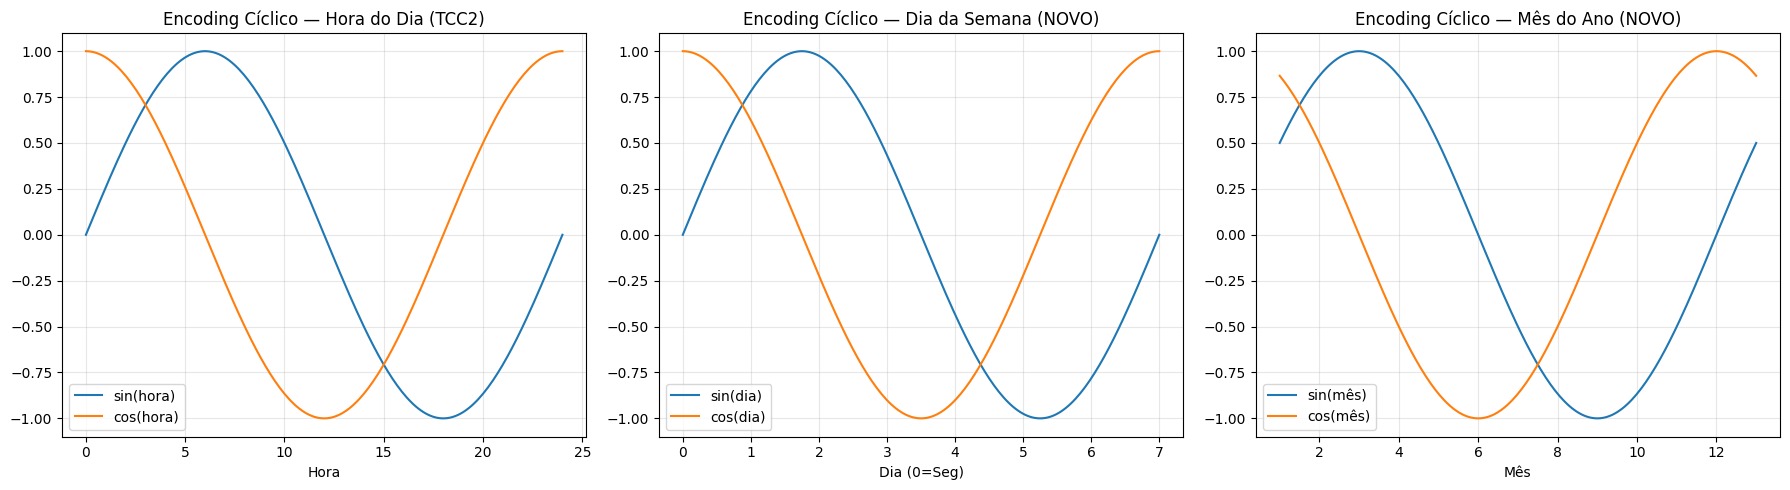

In [4]:
# Visualização do encoding cíclico
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hora
hours = np.linspace(0, 24, 200)
hr_s = np.sin(2*np.pi*hours/24)
hr_c = np.cos(2*np.pi*hours/24)
axes[0].plot(hours, hr_s, label='sin(hora)')
axes[0].plot(hours, hr_c, label='cos(hora)')
axes[0].set_title('Encoding Cíclico — Hora do Dia (TCC2)')
axes[0].set_xlabel('Hora')
axes[0].legend()

# Dia da semana
days = np.linspace(0, 7, 200)
axes[1].plot(days, np.sin(2*np.pi*days/7), label='sin(dia)')
axes[1].plot(days, np.cos(2*np.pi*days/7), label='cos(dia)')
axes[1].set_title('Encoding Cíclico — Dia da Semana (NOVO)')
axes[1].set_xlabel('Dia (0=Seg)')
axes[1].legend()

# Mês
months = np.linspace(1, 13, 200)
axes[2].plot(months, np.sin(2*np.pi*months/12), label='sin(mês)')
axes[2].plot(months, np.cos(2*np.pi*months/12), label='cos(mês)')
axes[2].set_title('Encoding Cíclico — Mês do Ano (NOVO)')
axes[2].set_xlabel('Mês')
axes[2].legend()

plt.tight_layout()
plt.show()

In [5]:
# Lag features de energia
df['energy_lag1'] = df['Value'].shift(1)    # energia 1h atrás (TCC2)
df['energy_lag2'] = df['Value'].shift(2)    # energia 2h atrás (NOVO)
df['energy_lag24'] = df['Value'].shift(24)  # energia 24h atrás / mesmo horário ontem (NOVO)

# Lag features de temperatura
df['temp_lag1'] = df['Temperature'].shift(1)  # temperatura 1h atrás (TCC2)
df['temp_lag2'] = df['Temperature'].shift(2)  # NOVO

print('Lag features criadas:')
print(df[['Timestamp','Value','energy_lag1','energy_lag2','energy_lag24',
           'Temperature','temp_lag1','temp_lag2']].iloc[23:28].to_string())

Lag features criadas:
                   Timestamp       Value  energy_lag1  energy_lag2  energy_lag24  Temperature  temp_lag1  temp_lag2
23 2015-07-04 13:30:00+00:00  507.392164   544.522407   544.253855           NaN         32.0       30.0       29.0
24 2015-07-04 14:30:00+00:00  545.783435   507.392164   544.522407   6997.984367         33.0       32.0       30.0
25 2015-07-04 15:30:00+00:00  522.314319   545.783435   507.392164  15518.012898         35.0       33.0       32.0
26 2015-07-04 16:30:00+00:00  514.841565   522.314319   545.783435   6674.491991         34.0       35.0       33.0
27 2015-07-04 17:30:00+00:00  553.295108   514.841565   522.314319   4920.282616         36.0       34.0       35.0


Rolling stats criadas:
                   Timestamp       Value  roll_mean_6h  roll_mean_24h  roll_std_24h
20 2015-07-04 10:30:00+00:00  496.875821    531.684451    3066.429302   3822.052044
21 2015-07-04 11:30:00+00:00  544.253855    534.299914    2951.784963   3768.502623
22 2015-07-04 12:30:00+00:00  544.522407    532.040574    2847.121374   3715.916702
23 2015-07-04 13:30:00+00:00  507.392164    528.814706    2749.632657   3665.485603
24 2015-07-04 14:30:00+00:00  545.783435    531.157077    2480.790951   3575.866490
25 2015-07-04 15:30:00+00:00  522.314319    526.857000    1855.970177   2270.737643


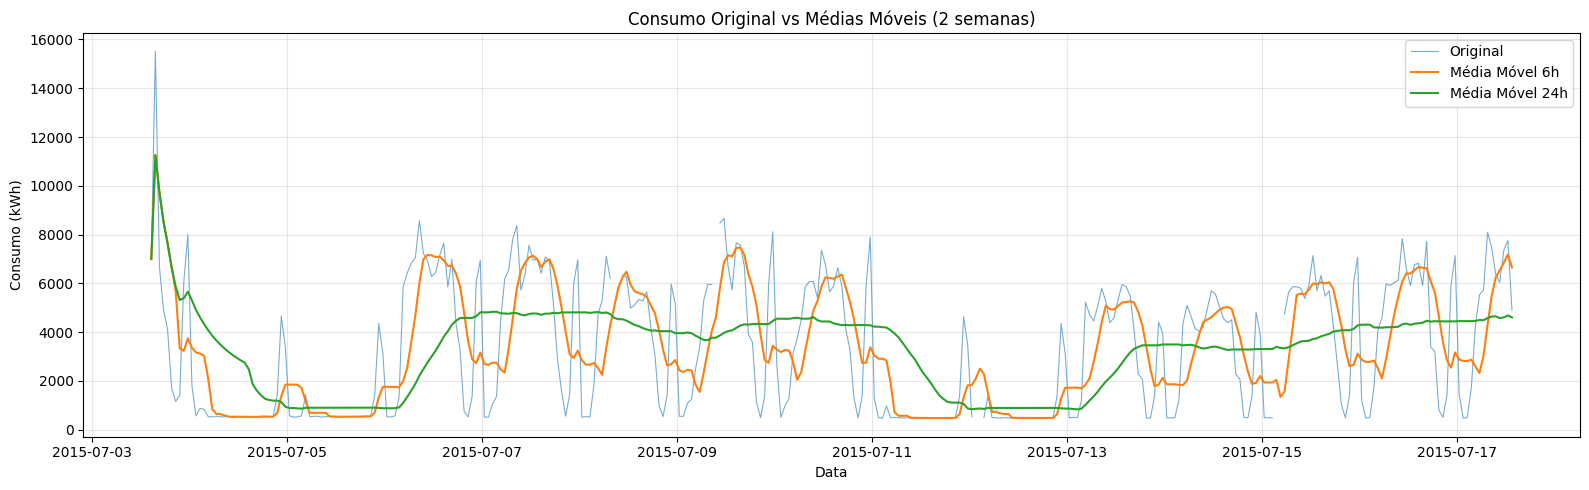

In [6]:
# Rolling statistics de energia
df['roll_mean_6h']  = df['Value'].rolling(window=6,  min_periods=1).mean()
df['roll_mean_24h'] = df['Value'].rolling(window=24, min_periods=1).mean()
df['roll_std_24h']  = df['Value'].rolling(window=24, min_periods=1).std()

# Rolling de temperatura
df['temp_roll_mean_6h'] = df['Temperature'].rolling(window=6,  min_periods=1).mean()

print('Rolling stats criadas:')
print(df[['Timestamp','Value','roll_mean_6h','roll_mean_24h','roll_std_24h']].iloc[20:26].to_string())

# Visualização
sample = df.iloc[:24*14].copy()  # 2 semanas
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sample['Timestamp'], sample['Value'], label='Original', alpha=0.6, linewidth=0.8)
ax.plot(sample['Timestamp'], sample['roll_mean_6h'],  label='Média Móvel 6h',  linewidth=1.5)
ax.plot(sample['Timestamp'], sample['roll_mean_24h'], label='Média Móvel 24h', linewidth=1.5)
ax.set_title('Consumo Original vs Médias Móveis (2 semanas)')
ax.set_xlabel('Data')
ax.set_ylabel('Consumo (kWh)')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Delta temperatura (variação brusca indica mudança de condição climática)
df['delta_temp'] = df['Temperature'].diff()   # NOVO

# Delta energia (taxa de variação do consumo)
df['delta_energy'] = df['Value'].diff()       # NOVO

# Interação temperatura × hora (captura aquecimento noturno)
df['temp_x_hour'] = df['Temperature'] * df['hour']  # NOVO

# Flags booleanas
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
# is_holiday já está em df (vindo da EDA)

print('Features de interação criadas.')
print(df[['Timestamp','delta_temp','delta_energy','temp_x_hour']].iloc[1:5].to_string())

Features de interação criadas.
                  Timestamp  delta_temp  delta_energy  temp_x_hour
1 2015-07-03 15:30:00+00:00         2.0   8520.028531        495.0
2 2015-07-03 16:30:00+00:00         1.0  -8843.520907        544.0
3 2015-07-03 17:30:00+00:00        -1.0  -1754.209375        561.0
4 2015-07-03 18:30:00+00:00         1.0   -801.495603        612.0


In [8]:
# Remove linhas com NaN (resultado dos lags e diffs)
df_feat = df.copy()
n_before = len(df_feat)
df_feat = df_feat.dropna()
n_after = len(df_feat)
print(f'Linhas removidas por NaN: {n_before - n_after} ({100*(n_before-n_after)/n_before:.1f}%)')
print(f'Shape final: {df_feat.shape}')

# Define as colunas de features e o alvo
TARGET = 'Value'

FEATURES_TCC2 = [
    'Temperature', 'temp_lag1',           # temperatura atual e anterior (TCC2)
    'energy_lag1',                         # energia anterior (TCC2)
    'hr_sin', 'hr_cos',                    # hora sin/cos (TCC2)
    'is_holiday',                          # feriado (TCC2)
]

FEATURES_NEW = [
    'Temperature', 'temp_lag1', 'temp_lag2',       # temperatura
    'energy_lag1', 'energy_lag2', 'energy_lag24',  # lags de energia
    'hr_sin', 'hr_cos',                            # hora (TCC2)
    'dow_sin', 'dow_cos',                          # dia da semana (NOVO)
    'month_sin', 'month_cos',                      # mês (NOVO)
    'roll_mean_6h', 'roll_mean_24h', 'roll_std_24h',  # rolling (NOVO)
    'delta_temp', 'delta_energy', 'temp_x_hour',   # interação/delta (NOVO)
    'is_weekend', 'is_holiday',                    # flags
]

print(f'\nFeatures TCC2 : {len(FEATURES_TCC2)}')
print(f'Features NOVAS: {len(FEATURES_NEW)}')

Linhas removidas por NaN: 363 (2.1%)
Shape final: (16632, 31)

Features TCC2 : 6
Features NOVAS: 20


In [9]:
# ── Normalização MinMaxScaler [-1, 1] (mesma abordagem do TCC2) ───────────────
scaler = MinMaxScaler(feature_range=(-1, 1))

cols_to_scale = FEATURES_NEW + [TARGET]
df_scaled = df_feat[['Timestamp'] + cols_to_scale].copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_feat[cols_to_scale])

print('Normalização aplicada (MinMaxScaler [-1,1]):')
print(df_scaled[cols_to_scale].describe().round(3))

Normalização aplicada (MinMaxScaler [-1,1]):
       Temperature  temp_lag1  temp_lag2  energy_lag1  energy_lag2  \
count    16632.000  16632.000  16632.000    16632.000    16632.000   
mean        -0.104     -0.105     -0.105       -0.635       -0.635   
std          0.357      0.357      0.357        0.280        0.280   
min         -1.000     -1.000     -1.000       -1.000       -1.000   
25%         -0.391     -0.391     -0.391       -0.892       -0.893   
50%         -0.130     -0.130     -0.130       -0.655       -0.656   
75%          0.130      0.130      0.130       -0.457       -0.457   
max          1.000      1.000      1.000        1.000        1.000   

       energy_lag24     hr_sin     hr_cos    dow_sin    dow_cos  ...  \
count     16632.000  16632.000  16632.000  16632.000  16632.000  ...   
mean         -0.635     -0.005     -0.008     -0.001     -0.050  ...   
std           0.279      0.712      0.715      0.725      0.745  ...   
min          -1.000     -1.000     -

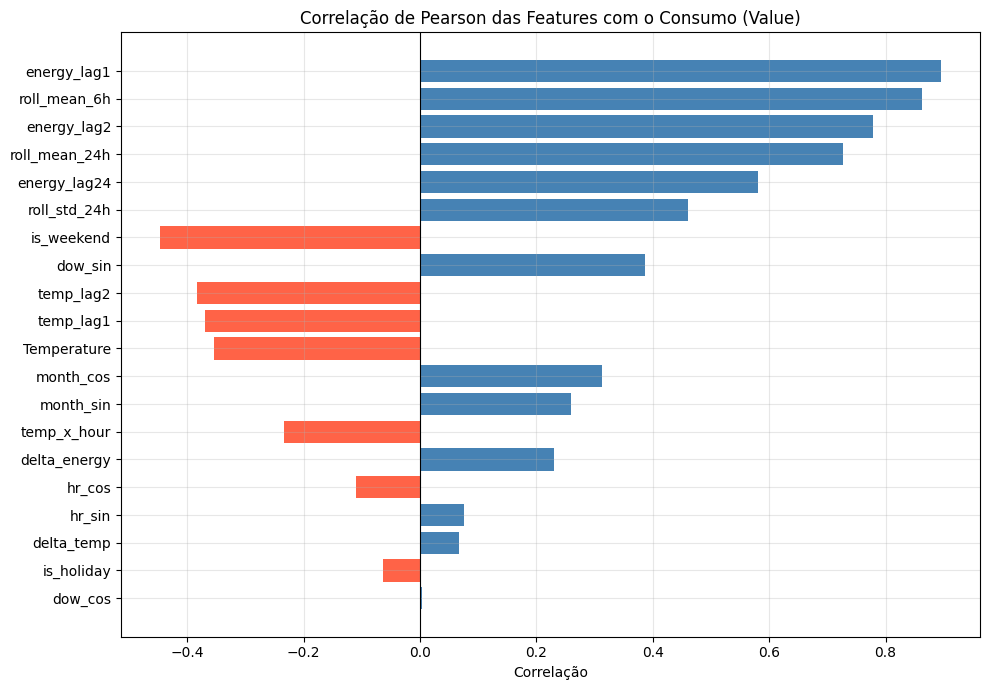

Top 10 correlações (abs):
energy_lag1      0.895219
roll_mean_6h     0.862882
energy_lag2      0.778029
roll_mean_24h    0.726341
energy_lag24     0.580144
roll_std_24h     0.460292
is_weekend      -0.446714
dow_sin          0.387065
temp_lag2       -0.383716
temp_lag1       -0.369543


In [10]:
corr_with_target = df_feat[FEATURES_NEW + [TARGET]].corr()[TARGET].drop(TARGET)
corr_with_target = corr_with_target.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if v >= 0 else 'tomato' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação de Pearson das Features com o Consumo (Value)')
ax.set_xlabel('Correlação')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 correlações (abs):')
print(corr_with_target.head(10).to_string())

In [11]:
# Salva dataset completo com todas as features (não normalizado — normalizar em cada modelo)
output_cols = ['Timestamp', TARGET] + FEATURES_NEW
df_out = df_feat[output_cols].copy()
df_out.to_csv(PROC + 'df_features.csv', index=False)
print(f'Salvo: {PROC}df_features.csv')
print(f'Shape: {df_out.shape}')
print(f'Colunas: {list(df_out.columns)}')
df_out.head(3)

Salvo: ../data/processed/df_features.csv
Shape: (16632, 22)
Colunas: ['Timestamp', 'Value', 'Temperature', 'temp_lag1', 'temp_lag2', 'energy_lag1', 'energy_lag2', 'energy_lag24', 'hr_sin', 'hr_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'roll_mean_6h', 'roll_mean_24h', 'roll_std_24h', 'delta_temp', 'delta_energy', 'temp_x_hour', 'is_weekend', 'is_holiday']


,Timestamp,Value,Temperature,temp_lag1,temp_lag2,energy_lag1,energy_lag2,energy_lag24,hr_sin,hr_cos,...,month_sin,month_cos,roll_mean_6h,roll_mean_24h,roll_std_24h,delta_temp,delta_energy,temp_x_hour,is_weekend,is_holiday
24,2015-07-04 14:30:00+00:00,545.783435,33.0,32.0,30.0,507.392164,544.522407,6997.984367,-0.608761,-0.793353,...,-0.5,-0.866025,531.157077,2480.790951,3575.866490,1.0,38.391270,462.0,1,0
25,2015-07-04 15:30:00+00:00,522.314319,35.0,33.0,32.0,545.783435,507.392164,15518.012898,-0.793353,-0.608761,...,-0.5,-0.866025,526.857000,1855.970177,2270.737643,2.0,-23.469116,525.0,1,0
26,2015-07-04 16:30:00+00:00,514.841565,34.0,35.0,33.0,522.314319,545.783435,6674.491991,-0.923880,-0.382683,...,-0.5,-0.866025,529.851291,1599.318076,2038.683756,-1.0,-7.472753,544.0,1,0
